In [43]:
%matplotlib inline
import cv2
import os
import numpy as np
from skimage.morphology import skeletonize
from scipy import ndimage
from skimage import img_as_ubyte
import matplotlib.pyplot as plt
from pathlib import Path
import utils

In [ ]:
image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/raw/ancre-habitee.jpg'
edges_rough_image_path = r'/home/tinmar/Desktop/Projects/Datasets/Puzzle/raw/ancre-habitee-edges.jpg'

if not os.path.exists(image_path):
    print(f"Image path does not exist: {image_path}")
if not os.path.exists(edges_rough_image_path):
    print(f"Edges rough image path does not exist: {edges_rough_image_path}")

color_img = cv2.imread(image_path)
mask_img = cv2.imread(edges_rough_image_path, cv2.IMREAD_GRAYSCALE)

kernel_size = 3
mask_img = cv2.dilate(mask_img, np.ones((kernel_size, kernel_size), np.uint8), iterations=1)

In [45]:
# Basic skeletonization
# Thresholding
_, binary_img = cv2.threshold(mask_img, 127, 255, cv2.THRESH_BINARY)

# 1. Scikit-image's skeletonize expects a boolean image (True where white, False where black)
# We convert the 0-255 image to boolean.
bool_img = binary_img > 0
# 2. Apply Skeletonization
# This is the core step that thins the lines to 1 pixel
skeleton_basic = skeletonize(bool_img)
skeleton_basic = (skeleton_basic * 255).astype(np.uint8)


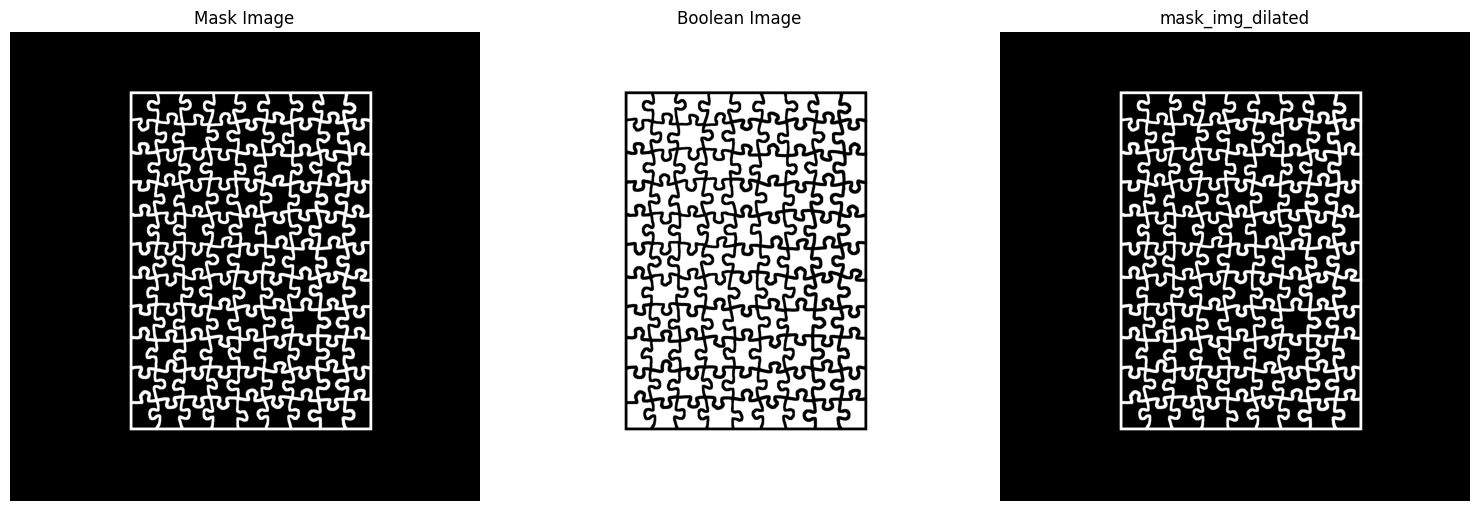

In [ ]:
utils.show_images_row([mask_img, bool_img], titles=["Mask Image", "Boolean Image"

In [47]:
# 2. Convert to Grayscale
gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

# 3. Find Local Minima (Darkest points)
# We use a footprint (e.g., 5x5) to find the darkest pixel in every local area
# This identifies the "bottom" of the dark grooves
local_min = ndimage.minimum_filter(gray, size=5)
dark_peaks_mask = (gray == local_min)

# 4. Constrain by your 5px Grid
# We only care about dark peaks that are inside your rough estimate
guided_mask = np.logical_and(dark_peaks_mask, mask_img > 0)

# 5. Skeletonize the guided mask
# Because the "local minima" might be slightly disconnected, 
# we dilate them slightly first to ensure connectivity, then skeletonize.
kernel_size = 10
kernel = np.ones((kernel_size, kernel_size), np.uint8)
connected_guidance = cv2.dilate(guided_mask.astype(np.uint8), kernel, iterations=1)

# final_skeleton = skeletonize(guided_mask > 0)
final_skeleton = skeletonize(connected_guidance > 0)

# Convert to 0-255 for saving/viewing
result = (final_skeleton * 255).astype(np.uint8)

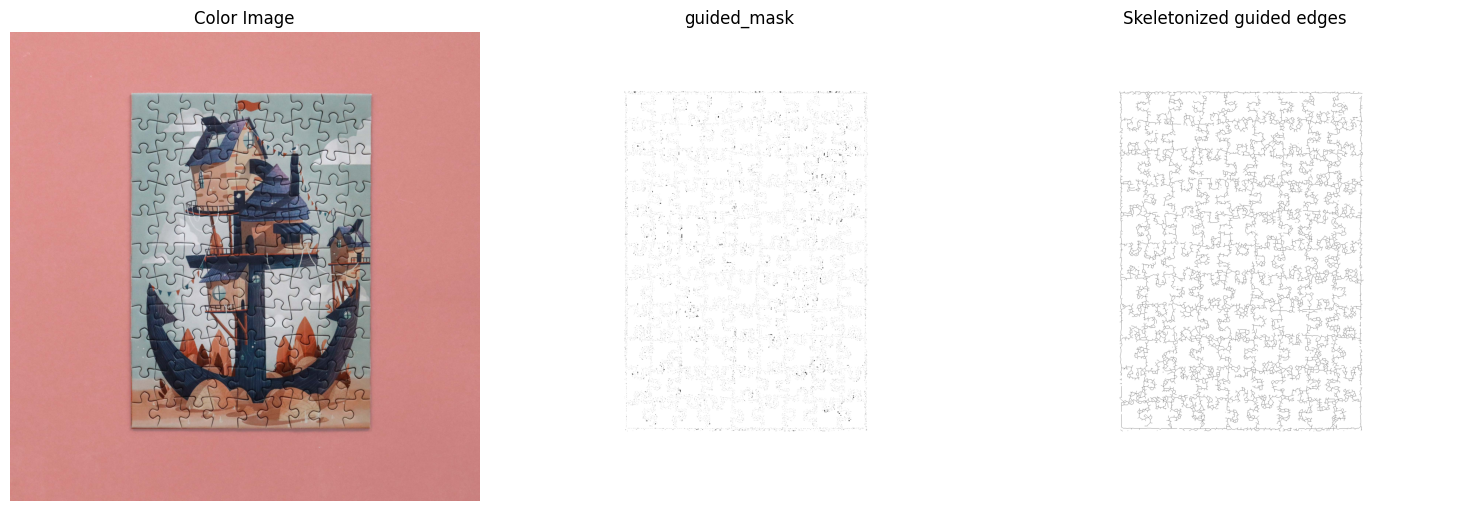

In [48]:
utils.show_images_row([color_img, guided_mask.astype(np.uint8)*255, result], titles=["Color Image", "guided_mask", "Skeletonized guided edges"])
